# **Installing Packages & Libraries**

In [ ]:
!pip install rdkit pubchempy torch torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.9 MB/s eta 0:00:00


# **Importing Libraries, Frameworks & Libraries**

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import requests
import seaborn as sns
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
import torch_geometric.transforms as T
from torch_geometric.utils import (
    negative_sampling, convert, to_dense_adj
)
from torch_geometric.nn import GCNConv, SAGEConv
import torch
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ExponentialLR, MultiplicativeLR

# **Data Loading & Processing**

In [ ]:
# t5_df = pd.read_csv('/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/T5_Embeddings.csv')
# t5_info = t5_df[['DrugID', 'Descriptions']]

# embedding_files = {
#     'Bert': '/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/Bert_Embeddings.csv',
#     'ChemBERTa': '/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/ChemBERTa_Embeddings.csv',
#     'RoBERTa': '/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/RoBERTa_Embeddings.csv',
#     'SBERT': '/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/SBERT_Embeddings.csv'
# }

# for model_name, file_path in embedding_files.items():
#     embedding_df = pd.read_csv(file_path)
#     # # Assuming the order of rows is the same in all embedding files
#     # merged_df = pd.concat([t5_info, embedding_df], axis=1)
#     # Drop the duplicate columns
#     merged_df = embedding_df.drop(columns=['DrugID.1', 'Descriptions.1'], errors='ignore')
#     merged_df.to_csv(file_path, index=False)
#     print(f"Updated {model_name}_Embeddings.csv")

Updated Bert_Embeddings.csv
Updated ChemBERTa_Embeddings.csv
Updated RoBERTa_Embeddings.csv
Updated SBERT_Embeddings.csv


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Interaction Information.csv")

In [ ]:
FDI_graph = pd.read_csv('/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Datasets/Edited Dataset/FDIGraph.csv')

# **Analyze Graph Structure**

In [ ]:
G = nx.from_pandas_edgelist(FDI_graph, 'src', 'dst')

In [ ]:
# Find the connected components
connected_components = nx.connected_components(G)

for component in connected_components:
    subgraph = G.subgraph(component)
    print("Subgraph Nodes:", subgraph.nodes())
    print("Subgraph Edges:", subgraph.edges())
    print("Subgraph Length:", len(subgraph))
    print()

Subgraph Nodes: ['D00572', 'F00001', 'D00230', 'D01002', 'D00065', 'D00265', 'D00241', 'D00370', 'D01217', 'D01334', 'D01104', 'D00770', 'D00756', 'D00073', 'D00188', 'F00002', 'D00199', 'F00003', 'D00043', 'F00005', 'F00006', 'F00007', 'D00245', 'F00008', 'D00070', 'D00741', 'D01036', 'D01057', 'D01174', 'D01061', 'F00009', 'D01194', 'D00108', 'F00010', 'D00403', 'D00032', 'F00011', 'D00016', 'D00240', 'D00036', 'D00589', 'D00257', 'F00012', 'D00774', 'D00127', 'D00149', 'F00013', 'D00259', 'F00014', 'F00015', 'D00864', 'D00250', 'F00016', 'F00017', 'D00093', 'F00018', 'D00194', 'D00754', 'D00291', 'F00019', 'D00687', 'D00894', 'D00828', 'D00878', 'D00751', 'D00511', 'D00508', 'D00799', 'D00611', 'D01455', 'D00453', 'D00968', 'D01465', 'F00020', 'D00019', 'D00498', 'F00021', 'D00142', 'D00384', 'D00984', 'F00022', 'D00200', 'D00406', 'F00023', 'D01209', 'F00024', 'D00267', 'D00815', 'D00806', 'D00619', 'D00126', 'D00688', 'D01210', 'D01222', 'D00509', 'D00152', 'D00060', 'D00001', 'D0

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
is_undirected = G.is_directed() is False

# Check if the graph is empty
if num_nodes == 0:
    average_node_degree = 0  # or any other appropriate value
else:
    average_node_degree = sum(dict(G.degree()).values()) / num_nodes

has_isolated_nodes = any(deg == 0 for _, deg in G.degree())
has_self_loops = any(G.has_edge(n, n) for n in G.nodes())

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
is_undirected = G.is_directed() is False
average_node_degree = sum(dict(G.degree()).values()) / num_nodes

has_isolated_nodes = any(deg == 0 for _, deg in G.degree())
has_self_loops = any(G.has_edge(n, n) for n in G.nodes())

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Is undirected: {is_undirected}")
print(f"Average node degree: {average_node_degree}")
print(f"Has isolated nodes: {has_isolated_nodes}")
print(f"Has self-loops: {has_self_loops}")

Number of nodes: 2462
Number of edges: 15022
Is undirected: True
Average node degree: 12.203086921202274
Has isolated nodes: False
Has self-loops: False


# **Graph Construction for PyTorch Geometric**

In [ ]:
def PyG_data(feature,DDI_graph):
  DrugIDs_in_graph = np.unique(DDI_graph.values)
  node_id_map = {node_name: i for i, node_name in enumerate(DrugIDs_in_graph)}
  # Replace node names with integer IDs in the edge list
  src = [node_id_map[node_name] for node_name in DDI_graph['src']]
  dst = [node_id_map[node_name] for node_name in DDI_graph['dst']]
  # Stack the arrays side by side to create a 2D array
  combined_array = np.column_stack((np.array(src), np.array(dst)))
  edge_index = []  # List of tuples representing edges between drugs
  for drug_1, drug_2 in combined_array:
    # Create an undirected graph by adding edges in both directions
    edge_index.append((drug_1, drug_2))
    edge_index.append((drug_2, drug_1))
  #Replace node names with integer IDs in the feature
  feature=torch.tensor(feature,dtype=torch.float32)
  data = Data(x=feature, edge_index=torch.tensor(edge_index).t().contiguous())
  return data

# **Negative Sampling & Link Prediction Split**

In [ ]:
transform = RandomLinkSplit(num_val=0.2,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=False,
    neg_sampling_ratio=1.0)
#train_data, val_data, test_data = transform(data)

# **Graph Neural Network Model**

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
    def encode(self, x, edge_index):
        x=self.conv1(x, edge_index)
        x=F.dropout(x, p=0.3)
        x=F.relu(x)
        x=self.conv2(x, edge_index)
        x=F.dropout(x, p=0.3)
        x=F.relu(x)
        x=self.conv3(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(
            dim=-1
        )  # product of a pair of nodes on each edge

    def decode_all(self, z):
        prob_adj = z @ z.t()
        return (prob_adj > 0).nonzero(as_tuple=False).t()

# **Training and Testing Functions**

In [ ]:
def train():
    model.train()
    optimizer.zero_grad()

    z = model.encode(train_data.x, train_data.edge_index) # initializing GCN model
    out = model.decode(z, edge_label_index).view(-1)
    loss = criterion(out, edge_label)
    loss.backward()
    optimizer.step()
    scheduler.step()
    return loss


@torch.no_grad()
def evaluate_model(data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index).view(-1).sigmoid()
    roc=roc_auc_score(data.edge_label.cpu().numpy(), out.cpu().numpy())
    label=data.edge_label.cpu().numpy()
    score=out.cpu().numpy()
    return roc,label,score

In [ ]:
df_descriptions = pd.read_csv('/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Datasets/Edited Dataset/Descriptions.csv')

In [ ]:
allowed_drug=list(df_descriptions['Descriptions'])

def LM(FDI_graph,allowed_drug,model_name,dir):
    Drug=pd.read_csv(dir,index_col=0)

    df = Drug[Drug.iloc[:, 0].isin(allowed_drug)]
    df=df.reset_index(drop=True)
    features=df.drop(df.columns[[0, 1]], axis=1)
    print(model_name)
    return  features.values, FDI_graph

# **Embedding Dictionary**

In [ ]:
Embedding_models={
                  # 'no_feature':no_feature(drugID_smiles_ddi,DDI_graph),
                  # 'BERTSMILES':LM(DDI_graph,allowed_drug,'BERT+SMILES','/content/drive/MyDrive/DATASETS/bert50mt_base_SMILES_embeddings.csv'),
                  # 'GPTSMILES':LM(DDI_graph,allowed_drug,'GPT+SMILES','/content/drive/MyDrive/DATASETS/SMILES_GPT.csv'),
                  # 'LLaMASMILES':LM(DDI_graph,allowed_drug,'LLaMA+SMILES','/content/drive/MyDrive/DATASETS/llama65b_base_SMILES_embeddings.csv'),
                  'BERT':LM(FDI_graph,allowed_drug,'BERT','/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/Bert_Embeddings.csv'),
                  'ChemBERTa':LM(FDI_graph,allowed_drug,'ChemBERTa','/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/ChemBERTa_Embeddings.csv'),
                  'RoBERTa':LM(FDI_graph,allowed_drug,'RoBERTa','/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/RoBERTa_Embeddings.csv'),
                  'SBERT':LM(FDI_graph,allowed_drug,'SBERT','/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/SBERT_Embeddings.csv'),
                  'T5':LM(FDI_graph,allowed_drug,'T5','/content/drive/MyDrive/VRSEC/IV Year/Mini 2/Sahith/Embeddings/T5_Embeddings.csv'),
                 }

BERT
ChemBERTa
RoBERTa
SBERT
T5


In [ ]:
lmbda = lambda epoch: 0.96

# **Hyperparameter Setup**

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Constants
LR = [0.01, 0.001, 0.0001, 0.0002, 0.0003, 0.00001]
model_names = ['BERT','ChemBERTa','RoBERTa','SBERT', 'T5']
AUC = pd.DataFrame(columns=['0.01', '0.001', '0.0001', '0.0002', '0.0003', '0.00001'])
PR = pd.DataFrame(columns=['0.01', '0.001', '0.0001', '0.0002', '0.0003', '0.00001'])
AUC['Embedding'] = model_names
PR['Embedding'] = model_names

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Training Loop
for lr in LR:
    results_AUC = []
    results_PR = []

    for model_name, emb in Embedding_models.items():
        print('-------------------------------')
        print(f'======== {model_name} =========')
        print('-------------------------------')

        # Prepare data and model
        data = PyG_data(emb[0], emb[1])
        train_data, val_data, test_data = transform(data)
        train_data, val_data, test_data = map(lambda d: d.to(device), [train_data, val_data, test_data])

        model = Net(data.num_features, 256, 256).to(device)
        optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)
        scheduler = MultiplicativeLR(optimizer, lr_lambda=lmbda)
        criterion = torch.nn.BCEWithLogitsLoss()

        # Prepare edge labels for training
        neg_edge_index = negative_sampling(
            edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
            num_neg_samples=train_data.edge_label_index.size(1), method='sparse'
        )
        edge_label_index = torch.cat([train_data.edge_label_index, neg_edge_index], dim=-1)
        edge_label = torch.cat([train_data.edge_label, train_data.edge_label.new_zeros(neg_edge_index.size(1))], dim=0)

        best_val_auc = 0
        final_test_auc = 0
        best_scores = None
        best_labels = None

        # Training loop
        for epoch in range(1, 100):
            loss = train()  # Call the provided train function
            val_auc, _, _ = evaluate_model(val_data)  # Call the provided test function for validation
            test_auc, labels, scores = evaluate_model(test_data)  # Call the test function for test data

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                final_test_auc = test_auc
                best_scores = scores
                best_labels = labels

            print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val AUC: {val_auc:.4f}, Test AUC: {test_auc:.4f}')

        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(best_labels, best_scores)
        pr_auc = auc(recall, precision)

        # Collect results
        results_AUC.append({"Embedding": model_name, "AUC": final_test_auc})
        results_PR.append({"Embedding": model_name, "PR_AUC": pr_auc})

        # Clear GPU memory
        del data, model
        torch.cuda.empty_cache()

    # Update results in AUC and PR DataFrames
    results_AUC_df = pd.DataFrame(results_AUC)
    results_PR_df = pd.DataFrame(results_PR)

    AUC[str(lr)] = results_AUC_df['AUC']
    PR[str(lr)] = results_PR_df['PR_AUC']

-------------------------------
======== BERT =========
-------------------------------
Epoch: 001, Loss: 2.4702, Val AUC: 0.5000, Test AUC: 0.5000
Epoch: 002, Loss: 209.5701, Val AUC: 0.9425, Test AUC: 0.9591
Epoch: 003, Loss: 2.4399, Val AUC: 0.9404, Test AUC: 0.9545
Epoch: 004, Loss: 1.8382, Val AUC: 0.9367, Test AUC: 0.9535
Epoch: 005, Loss: 0.9409, Val AUC: 0.9357, Test AUC: 0.9461
Epoch: 006, Loss: 0.6128, Val AUC: 0.8951, Test AUC: 0.9221
Epoch: 007, Loss: 0.6346, Val AUC: 0.8992, Test AUC: 0.9155
Epoch: 008, Loss: 0.6077, Val AUC: 0.9244, Test AUC: 0.9513
Epoch: 009, Loss: 0.6213, Val AUC: 0.9239, Test AUC: 0.9495
Epoch: 010, Loss: 0.6255, Val AUC: 0.9128, Test AUC: 0.9425
Epoch: 011, Loss: 0.6054, Val AUC: 0.9236, Test AUC: 0.9393
Epoch: 012, Loss: 0.5958, Val AUC: 0.9266, Test AUC: 0.9405
Epoch: 013, Loss: 0.5749, Val AUC: 0.9310, Test AUC: 0.9399
Epoch: 014, Loss: 0.5830, Val AUC: 0.9155, Test AUC: 0.9499
Epoch: 015, Loss: 0.5687, Val AUC: 0.9020, Test AUC: 0.9187
Epoch: 016

# **Evaluation and Visualization**

In [ ]:
AUC.to_csv('AUC_BioSnap.csv')
PR.to_csv('PR_BioSnap.csv')

In [ ]:
# AUC = pd.read_csv('AUC_BioSnap.csv')
# PR = pd.read_csv('PR_BioSnap.csv')

In [ ]:
AUC.index=AUC['Embedding']
AUC_edited=AUC.drop(['0.00001','Embedding'],axis=1)
AUC_edited

,0.01,0.001,0.0001,0.0002,0.0003,1e-05
Embedding,,,,,,
BERT,0.959069,0.969864,0.969770,0.970800,0.965044,0.964890
ChemBERTa,0.959747,0.965724,0.965963,0.965215,0.963622,0.939656
RoBERTa,0.953721,0.968416,0.964567,0.964481,0.960886,0.960724
SBERT,0.967296,0.969002,0.974213,0.975128,0.969643,0.953399
T5,0.960734,0.968830,0.962994,0.972636,0.968512,0.955946


In [ ]:
PR.index=AUC['Embedding']
PR_edited=PR.drop(['0.00001','Embedding'],axis=1)
PR_edited

,0.01,0.001,0.0001,0.0002,0.0003,1e-05
Embedding,,,,,,
BERT,0.954411,0.961527,0.956146,0.957826,0.958053,0.959164
ChemBERTa,0.945164,0.957036,0.955010,0.955965,0.959365,0.943471
RoBERTa,0.945398,0.958348,0.955237,0.958194,0.949925,0.959004
SBERT,0.959380,0.958072,0.970575,0.969540,0.958613,0.938574
T5,0.953717,0.957361,0.948720,0.963639,0.961892,0.942213


/tmp/ipython-input-481246431.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=AUC_edited.index, y='0.0002', data=AUC_edited,palette="Pastel1")


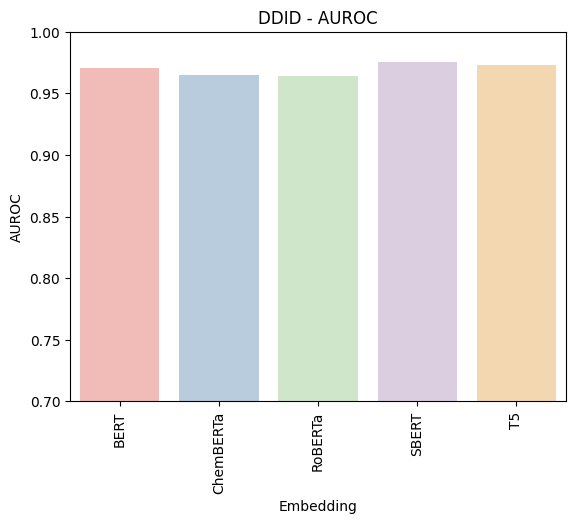

In [ ]:
ax=sns.barplot(x=AUC_edited.index, y='0.0002', data=AUC_edited,palette="Pastel1")
ax.set_title('DDID - AUROC')
ax.set(ylabel='AUROC')
ax.set_ylim(0.7,1)
ax.tick_params(axis='x', rotation=90)

/tmp/ipython-input-1160811167.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=PR_edited.index, y='0.0002', data=PR_edited,palette="PiYG")


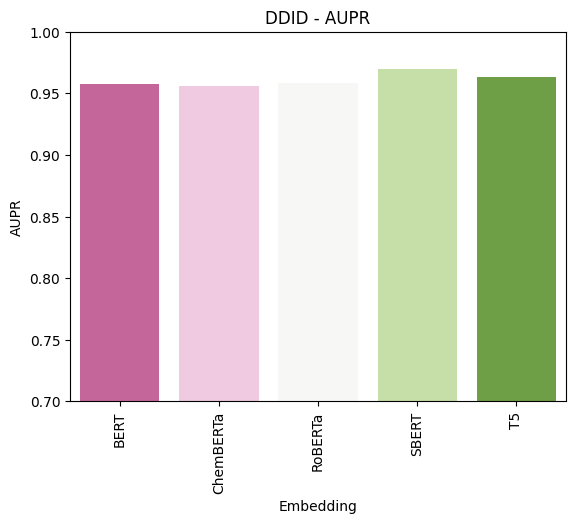

In [ ]:
ax=sns.barplot(x=PR_edited.index, y='0.0002', data=PR_edited,palette="PiYG")
ax.set_title('DDID - AUPR')
ax.set(ylabel='AUPR')
ax.set_ylim(0.7,1)
ax.tick_params(axis='x', rotation=90)